<a href="https://colab.research.google.com/github/SampathJyotsna-coder/Thiranex/blob/main/project_1_Thiranex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== RAW DATA ==========
   Customer_ID   Age  Gender     City Product_Category  Purchase_Amount  \
0         1051  33.0  Female  Chennai           Sports          29365.0   
1         1092  20.0  Female   Mumbai          Fashion           7145.0   
2         1014  37.0    Male   Mumbai        Groceries          38500.0   
3         1071  41.0  Female  Chennai        Groceries          27237.0   
4         1060  50.0    Male  Chennai          Fashion          11985.0   

   Rating  
0       3  
1       5  
2       2  
3       4  
4       2  

========== DATA CLEANING ==========

Missing Values:
Customer_ID          0
Age                 16
Gender               0
City                 0
Product_Category     0
Purchase_Amount      6
Rating               0
dtype: int64

Duplicates Removed: 10

Outliers Removed Successfully!

========== DATA ANALYSIS ==========

Dataset Shape:
(298, 7)

Statistical Summary:
       Customer_ID         Age  Purchase_Amount      Rating
count   298.000000

/tmp/ipykernel_6339/2252099637.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_6339/2252099637.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

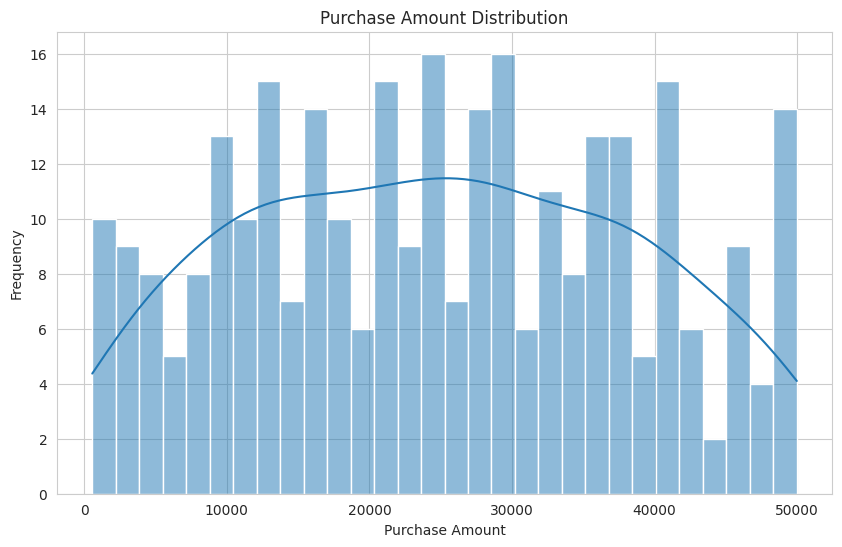

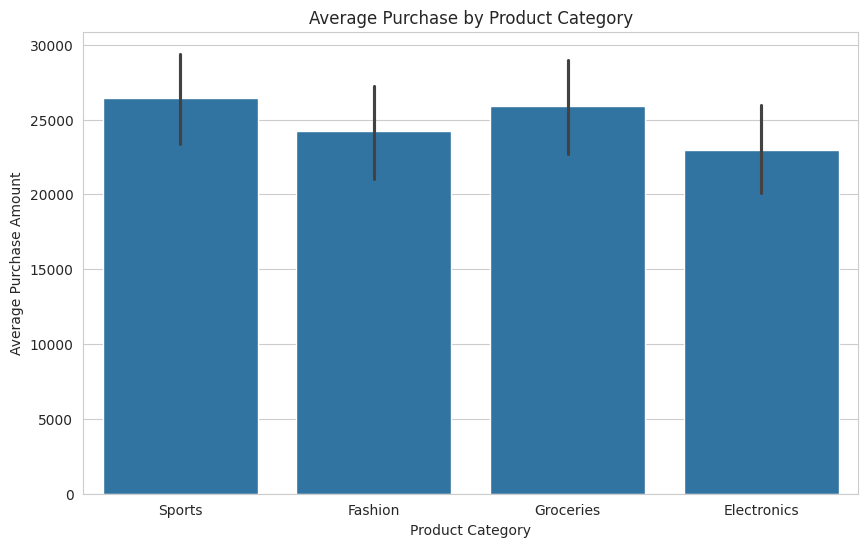

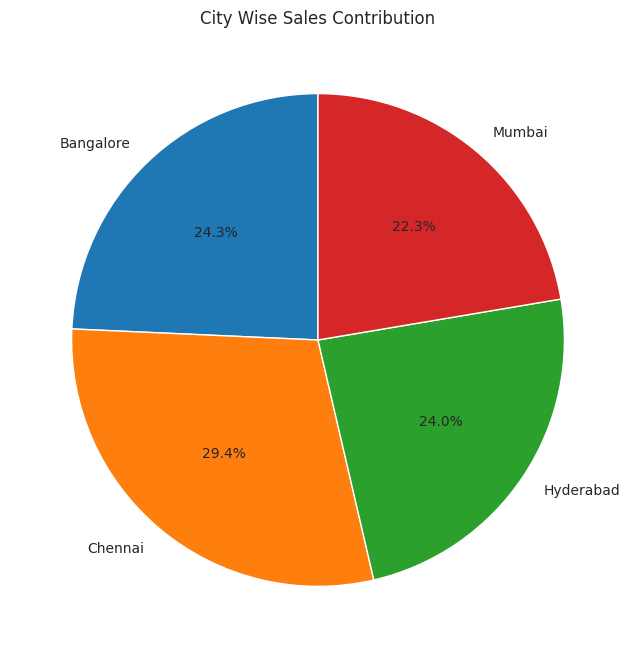

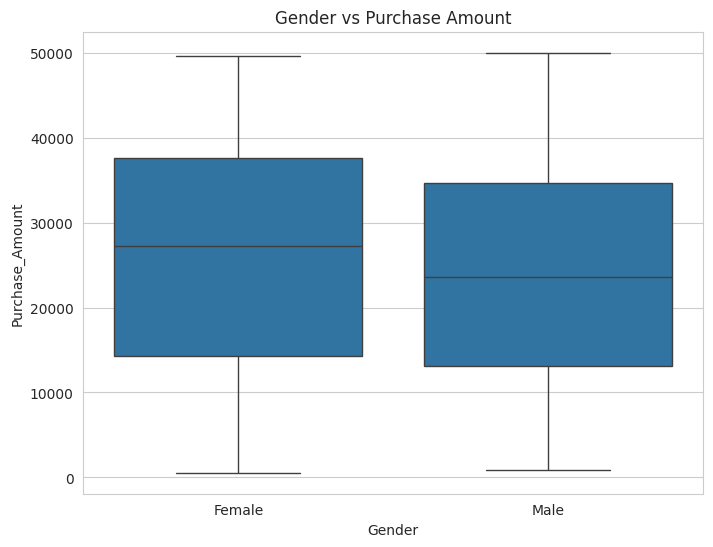

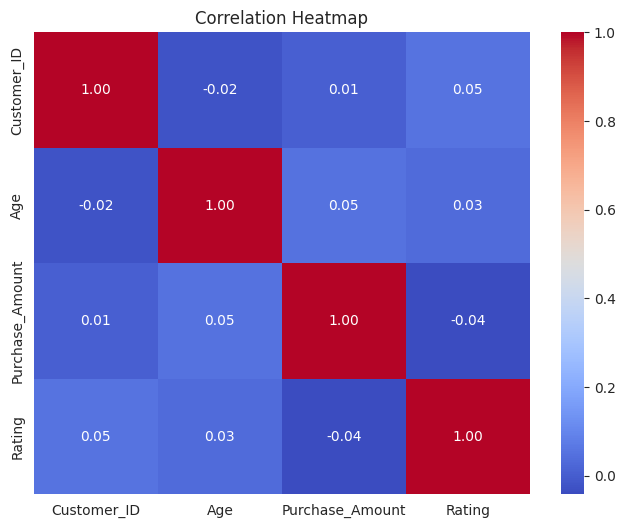


========== KEY INSIGHTS ==========
Highest Spending Category : Sports
Top Performing City : Chennai

Project Completed Successfully!
Data Cleaning + Visualization + Insights Generated


In [1]:
# =========================================================
# DATA CLEANING & VISUALIZATION PROJECT
# Advanced Internship Project using Python
# =========================================================

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# STEP 1 : CREATE RAW DATASET
# ---------------------------------------------------------

np.random.seed(42)

# Creating sample raw sales dataset
data = {
    "Customer_ID": np.random.randint(1000, 1100, 300),
    "Age": np.random.randint(18, 65, 300),
    "Gender": np.random.choice(["Male", "Female"], 300),
    "City": np.random.choice(["Hyderabad", "Chennai", "Bangalore", "Mumbai"], 300),
    "Product_Category": np.random.choice(
        ["Electronics", "Fashion", "Groceries", "Sports"], 300
    ),
    "Purchase_Amount": np.random.randint(500, 50000, 300),
    "Rating": np.random.randint(1, 6, 300)
}

df = pd.DataFrame(data)

# ---------------------------------------------------------
# STEP 2 : ADD MISSING VALUES & DUPLICATES
# ---------------------------------------------------------

# Add Missing Values
df.loc[5:15, "Age"] = np.nan
df.loc[20:25, "Purchase_Amount"] = np.nan

# Add Duplicate Rows
df = pd.concat([df, df.iloc[0:10]], ignore_index=True)

# Add Outliers
df.loc[50, "Purchase_Amount"] = 300000
df.loc[100, "Purchase_Amount"] = 450000

print("========== RAW DATA ==========")
print(df.head())

# ---------------------------------------------------------
# STEP 3 : DATA CLEANING
# ---------------------------------------------------------

print("\n========== DATA CLEANING ==========")

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill Missing Values
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Purchase_Amount"].fillna(df["Purchase_Amount"].mean(), inplace=True)

# Remove Duplicates
duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed: {duplicates}")

# ---------------------------------------------------------
# STEP 4 : OUTLIER DETECTION & REMOVAL
# ---------------------------------------------------------

Q1 = df["Purchase_Amount"].quantile(0.25)
Q3 = df["Purchase_Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove Outliers
df = df[
    (df["Purchase_Amount"] >= lower_limit) &
    (df["Purchase_Amount"] <= upper_limit)
]

print("\nOutliers Removed Successfully!")

# ---------------------------------------------------------
# STEP 5 : DATA ANALYSIS
# ---------------------------------------------------------

print("\n========== DATA ANALYSIS ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nStatistical Summary:")
print(df.describe())

print("\nAverage Purchase by Category:")
print(df.groupby("Product_Category")["Purchase_Amount"].mean())

# ---------------------------------------------------------
# STEP 6 : DATA VISUALIZATION
# ---------------------------------------------------------

sns.set_style("whitegrid")

# ---------------------------------------------------------
# Visualization 1 : Purchase Distribution
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["Purchase_Amount"], bins=30, kde=True)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------------------------
# Visualization 2 : Sales by Product Category
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Product_Category",
    y="Purchase_Amount",
    data=df,
    estimator=np.mean
)
plt.title("Average Purchase by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase Amount")
plt.show()

# ---------------------------------------------------------
# Visualization 3 : City Wise Sales
# ---------------------------------------------------------

city_sales = df.groupby("City")["Purchase_Amount"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    city_sales,
    labels=city_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("City Wise Sales Contribution")
plt.show()

# ---------------------------------------------------------
# Visualization 4 : Gender vs Purchase
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.boxplot(x="Gender", y="Purchase_Amount", data=df)
plt.title("Gender vs Purchase Amount")
plt.show()

# ---------------------------------------------------------
# Visualization 5 : Correlation Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# ---------------------------------------------------------
# STEP 7 : KEY INSIGHTS
# ---------------------------------------------------------

print("\n========== KEY INSIGHTS ==========")

highest_category = (
    df.groupby("Product_Category")["Purchase_Amount"]
    .mean()
    .idxmax()
)

highest_city = (
    df.groupby("City")["Purchase_Amount"]
    .sum()
    .idxmax()
)

print(f"Highest Spending Category : {highest_category}")
print(f"Top Performing City : {highest_city}")

print("\nProject Completed Successfully!")
print("Data Cleaning + Visualization + Insights Generated")

# =========================================================
# END OF PROJECT
# =========================================================